<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/GD_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from  sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, RegressorMixin

In [2]:
X,y = make_regression(n_samples=100 , n_features=1, n_informative=1 , n_targets=1 , noise=20)

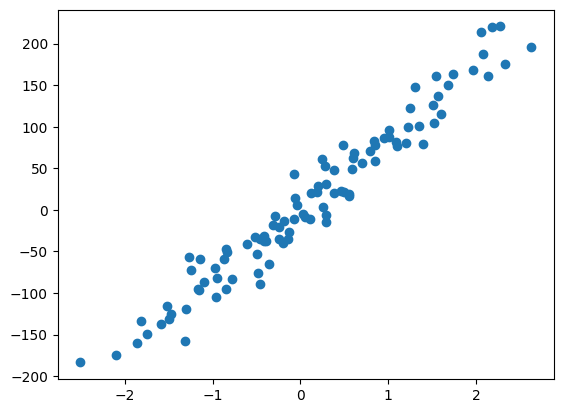

In [3]:
plt.scatter(X,y)

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
lr = LinearRegression()

In [6]:
lr.fit(X,y)

LinearRegression()

In [8]:
print(lr.coef_)
print(lr.intercept_)

[83.69430863]
0.5385595219577954


In [38]:
np.mean(cross_val_score(lr,X,y,scoring="neg_mean_squared_error"))

np.float64(-501.26902242296876)

In [9]:
m = 29.19

In [63]:
class GDRegressor(BaseEstimator, RegressorMixin) :
  def __init__(self,learning_rate=0.001 ,epochs=100):
    self.m = 100
    self.b = -120
    self.lr = learning_rate
    self.epochs =  epochs

  def fit(self, X, y) :
    for i in range(self.epochs):
      loss_slope_b = - 2 * np.sum(y - self.m*X.ravel()- self.b)
      loss_slope_m = -2*np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
      self.b = self.b - (self.lr*loss_slope_b)
      self.m = self.m - (self.lr*loss_slope_m)
      # print(self.m , self.b) # Commenting out print to avoid verbose output during cross-validation
    return self # Estimators should return self after fitting

  def predict(self, X):
    return self.m*X + self.b

In [56]:
gd = GDRegressor(0.001,100)

In [57]:
gd.fit(X,y)

99.059785057175 -96.33675081426708
97.7182252877887 -77.38052296087673
96.20764000484417 -62.178972262338974
94.67418026696168 -49.9765559676026
93.20552514871756 -40.17282368095181
91.850263184367 -32.28980505376876
90.6313618611545 -25.946448239931797
89.55544952590476 -20.838537813386207
88.61914434242375 -16.722882109653476
87.81331197851748 -13.404835614607
87.12587973142479 -10.728432932095487
86.54365239965585 -8.568572665849533
86.05344449087332 -6.8248140222846025
85.64274990762578 -5.416444954617427
85.30010364051772 -4.278554932542528
85.01524267405185 -3.3589030170542835
84.77913982080753 -2.615416706297576
84.58396061017581 -2.0141919345048844
84.42297683374629 -1.5278918960133139
84.29045885166963 -1.134463747886809
84.18156082919361 -0.8161090364863268
84.09220765166873 -0.5584569104881121
84.018988610602 -0.3498996088123959
83.95906052924893 -0.1810579530465759
83.91006142502181 -0.044351100768175056
83.87003481989343 0.06635000519842846
83.83736422059938 0.156001940533

In [59]:
gd.predict(X)

array([[ -65.19140906],
       [ -39.75037537],
       [ -70.60299373],
       [  24.88010943],
       [  41.19590307],
       [ -79.59104445],
       [ 105.13054554],
       [  93.03043607],
       [ 141.55618948],
       [-109.91085894],
       [ 179.07987929],
       [ -15.56988902],
       [   3.00384618],
       [  -2.34640431],
       [ -29.73483381],
       [  17.60433476],
       [-108.97676915],
       [ 183.59955869],
       [ -20.21199143],
       [  20.94410472],
       [   4.4353942 ],
       [ -37.92741333],
       [ 127.91536907],
       [ -97.50717004],
       [  -5.41257324],
       [  71.77168516],
       [  42.40491663],
       [  10.7846122 ],
       [ 101.10604037],
       [  -5.50904511],
       [  51.17006217],
       [ -91.06677195],
       [ -96.43861126],
       [  47.04951877],
       [  66.94535323],
       [-155.42950097],
       [ -81.09756286],
       [ -34.30794101],
       [ 190.69783256],
       [ -50.93388384],
       [ 113.59819987],
       [-132.789

In [64]:
np.mean(cross_val_score(lr,X,y,scoring='r2',cv=10))

np.float64(0.9315153829542842)

In [65]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [66]:
lr = LinearRegression()

In [67]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[82.71860118]
0.6396300055167288


In [68]:
y_pred = lr.predict(X_test)

In [70]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9046591895012853

In [71]:
class GDRegressor(BaseEstimator, RegressorMixin) :
  def __init__(self,learning_rate=0.001 ,epochs=100):
    self.m = 100
    self.b = -120
    self.lr = learning_rate
    self.epochs =  epochs

  def fit(self, X, y) :
    for i in range(self.epochs):
      loss_slope_b = - 2 * np.sum(y - self.m*X.ravel()- self.b)
      loss_slope_m = -2*np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
      self.b = self.b - (self.lr*loss_slope_b)
      self.m = self.m - (self.lr*loss_slope_m)
      print(self.m , self.b)

  def predict(self, X):
    return self.m*X + self.b

In [72]:
gd = GDRegressor(0.001,100)

In [74]:
gd.fit(X_train,y_train)

83.48005922057023 0.5239686121108688
83.31401519476915 0.5184671773126321
83.18514745846672 0.5190810099950547
83.08497848921137 0.5236595728877985
83.00698777897077 0.5306636941069789
82.94615643916988 0.5390060479207119
82.898618319626 0.5479315162896554
82.86139264744267 0.5569276920872055
82.83217906886742 0.5656581311684176
82.80920047041339 0.5739127460305192
82.79108239121605 0.5815710920251821
82.77676046580747 0.5885753296654052
82.76540934567345 0.594910431108552
82.7563880846615 0.600589794564046
82.74919814877644 0.6056448822853073
82.74345111016864 0.6101178403506154
82.73884377318673 0.6140563178233376
82.7351390069205 0.617509899072608
82.73215096168522 0.620527711234504
82.72973365543807 0.623156880574281
82.72777215237468 0.6254415956782412
82.72617573690734 0.6274225986562112
82.72487262486058 0.6291369729625153
82.72380585996423 0.6306181319110769
82.72293012517322 0.6318959384035182
82.72220926080873 0.6329969060335094
82.72161432944002 0.633944446262493
82.72112210

In [75]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9046591895012853